### ML: Is the customer going to buy the product that he is looking at or not?
### The whole dataset is big and it is available [ here :](https://www.kaggle.com/datasets/otto/recsys-dataset)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

In [2]:
df_original = pd.read_csv('events_10000_sessions.csv')
df_original

,aid,ts,type,session,datetime,date,hour,weekday
0,1517085,1659304800025,clicks,0,2022-07-31 22:00:00.025,2022-07-31,22,Sunday
1,1563459,1659304904511,clicks,0,2022-07-31 22:01:44.511,2022-07-31,22,Sunday
2,1309446,1659367439426,clicks,0,2022-08-01 15:23:59.426,2022-08-01,15,Monday
3,16246,1659367719997,clicks,0,2022-08-01 15:28:39.997,2022-08-01,15,Monday
4,1781822,1659367871344,clicks,0,2022-08-01 15:31:11.344,2022-08-01,15,Monday
...,...,...,...,...,...,...,...,...
628742,1121381,1661617374727,carts,9999,2022-08-27 16:22:54.727,2022-08-27,16,Saturday
628743,1021005,1661617430111,clicks,9999,2022-08-27 16:23:50.111,2022-08-27,16,Saturday
628744,554476,1661617485935,clicks,9999,2022-08-27 16:24:45.935,2022-08-27,16,Saturday
628745,1021005,1661617498509,clicks,9999,2022-08-27 16:24:58.509,2022-08-27,16,Saturday


In [3]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 628747 entries, 0 to 628746
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   aid       628747 non-null  int64
 1   ts        628747 non-null  int64
 2   type      628747 non-null  str  
 3   session   628747 non-null  int64
 4   datetime  628747 non-null  str  
 5   date      628747 non-null  str  
 6   hour      628747 non-null  int64
 7   weekday   628747 non-null  str  
dtypes: int64(4), str(4)
memory usage: 38.4 MB


#### No missing values 
#### 4 columns integers (aid - ts - session - hour)
#### 4 columns strings (type - datetime - date weekday)

In [4]:
df_original.head()

,aid,ts,type,session,datetime,date,hour,weekday
0,1517085,1659304800025,clicks,0,2022-07-31 22:00:00.025,2022-07-31,22,Sunday
1,1563459,1659304904511,clicks,0,2022-07-31 22:01:44.511,2022-07-31,22,Sunday
2,1309446,1659367439426,clicks,0,2022-08-01 15:23:59.426,2022-08-01,15,Monday
3,16246,1659367719997,clicks,0,2022-08-01 15:28:39.997,2022-08-01,15,Monday
4,1781822,1659367871344,clicks,0,2022-08-01 15:31:11.344,2022-08-01,15,Monday


### Count events by type:
* counts clicks, carts, and orders and visualizes their frequencies in a bar chart. This reveals how common each customer action is in the dataset.

type
clicks    571560
carts      45202
orders     11985
Name: count, dtype: int64


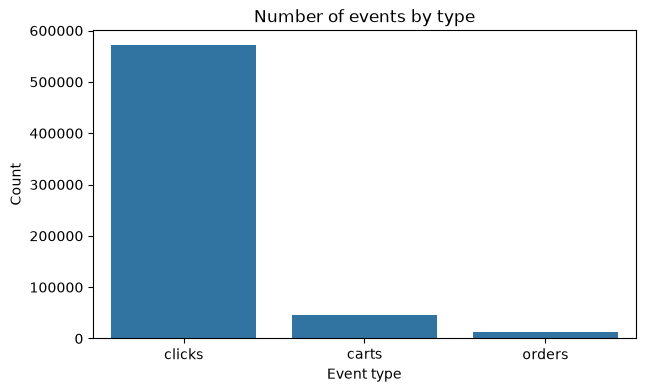

In [5]:
event_counts = df_original["type"].value_counts()

print(event_counts)

plt.figure(figsize=(7, 4))
sns.barplot(
    x=event_counts.index,
    y=event_counts.values
)
plt.title("Number of events by type")
plt.xlabel("Event type")
plt.ylabel("Count")
plt.show()